In [342]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils
import TCR_embedings

In [343]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

In [344]:
importlib.reload(TCR_embedings)

<module 'TCR_embedings' from '/ihome/ylee/yiz133/Code/Data processing/functions/TCR_embedings.py'>

In [345]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external"

/ix1/ylee/Yifan_Zhang/Code_data/external


In [554]:
mdata_ori = mu.read("merged_EAE.h5mu")

In [555]:
mdata = mdata_ori.copy()

In [556]:
mdata['airr'].obs['GSE'] = mdata.obs['GSE']
mdata['airr'].obs['GSE'].value_counts()

GSE
LEE          43558
GSE188320    39758
GSE182747    37164
GSE293883    11097
GSE156718    10848
GSE178085      511
Name: count, dtype: int64

In [636]:
mdata

MuData object with n_obs × n_vars = 11545 × 5000
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'set'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call'
  2 modalities
    gex:	11545 x 5000
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE', 'CV_score_0', 'CV_score_1', 'CV_score_2', 'CV_score_3', 'CV_score_0_high', 'CV_score_1_high', 'CV_score_2_high', 'CV_score_3_high', 'CNS_vs_rest'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'hvg', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap', 'rank_genes_groups'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	11545 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition', 'GSE'
      obsm:	'airr', 'chain_indices'

In [638]:
mdata['gex'].obs['Tissue_group'] = mdata['gex'].obs['tissue'].apply(lambda x: 'CNS' if x == 'CNS' else 'non-CNS')
mdata['gex'].obs['Tissue_group'].value_counts()

Tissue_group
non-CNS    5365
CNS        4863
Name: count, dtype: int64

# Settings

In [ ]:
min_clone = 1
mdata_sets = {'all': mdata,
            'cloned': mdata_cloned,
            'one_in_each_clone': mdata_cloned_oneCell}
mdata_sub = mdata_sets['cloned']



# Subsets

#### Cell type subset

In [557]:
# print(mdata.obs['condition'].value_counts())
# print(mdata.obs['cell_type'].value_counts())
# print(mdata['gex'].obs['tissue'].value_counts())

In [558]:
# mdata = mdata[mdata.obs['condition'].isin(['EAE'])]
# mdata = mdata[~mdata.obs['cell_type'].isin(['CD8'])]

In [559]:
mdata

MuData object with n_obs × n_vars = 142936 × 5000
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state'
  2 modalities
    gex:	142936 x 5000
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'hvg', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	142936 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition', 'GSE'
      obsm:	'airr', 'chain_indices'

#### only cloned TCRs

In [589]:
mdata_cloned = mdata[mdata['airr'].obs['clone_id_size'].fillna(0).astype('int') > min_clone].copy()
mdata_cloned['airr'].obs['GSE'].value_counts()

GSE
GSE188320    28352
GSE182747    26215
LEE           6310
GSE156718     3182
GSE293883     2483
GSE178085      511
Name: count, dtype: int64

#### select only one cell from each clonotype

In [561]:
# Randomly keep one cell per clone_id within each GSE subset
airr = mdata_cloned['airr']
print(f"Original number of cells: {airr.n_obs}")

# Store indices to keep
indices_to_keep = []

# Group by GSE
for gse in airr.obs['GSE'].unique():
    # Get cells for this GSE
    gse_mask = airr.obs['GSE'] == gse
    gse_obs = airr.obs[gse_mask]
    
    print(f"\nGSE: {gse} - Original cells: {len(gse_obs)}")
    
    # For each clone_id in this GSE, randomly select one cell
    for clone_id in gse_obs['clone_id'].unique():
        clone_cells = gse_obs[gse_obs['clone_id'] == clone_id]
        # Randomly sample one cell from this clone
        selected_idx = clone_cells.sample(n=1, random_state=42).index[0]
        indices_to_keep.append(selected_idx)
    
    print(f"GSE: {gse} - After sampling: {len(gse_obs['clone_id'].unique())} cells (one per clone)")

# Create subset with selected cells
mdata_cloned_oneCell = mdata[indices_to_keep].copy()


Original number of cells: 67053

GSE: LEE - Original cells: 6310
GSE: LEE - After sampling: 1689 cells (one per clone)

GSE: GSE156718 - Original cells: 3182
GSE: GSE156718 - After sampling: 1111 cells (one per clone)

GSE: GSE182747 - Original cells: 26215
GSE: GSE182747 - After sampling: 3542 cells (one per clone)

GSE: GSE293883 - Original cells: 2483
GSE: GSE293883 - After sampling: 652 cells (one per clone)

GSE: GSE178085 - Original cells: 511
GSE: GSE178085 - After sampling: 2 cells (one per clone)

GSE: GSE188320 - Original cells: 28352
GSE: GSE188320 - After sampling: 4549 cells (one per clone)


## select subset

In [590]:
mdata = mdata_cloned
mdata

MuData object with n_obs × n_vars = 11545 × 5000
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state'
  2 modalities
    gex:	11545 x 5000
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'hvg', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	11545 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition', 'GSE'
      obsm:	'airr', 'chain_indices'

# embed TCR AA into vector

In [591]:
tcr_aa_obs = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']
tcr_num_features = []

In [592]:
# Atchley factors for the 20 amino acids
atchley_factors = {
    'A': [ 0.591, -1.302, -0.733,  1.570, -0.146],  # Alanine
    'R': [ 1.538,  0.055,  1.502,  0.440,  2.897],  # Arginine
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],  # Asparagine
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],  # Aspartic acid
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],  # Cysteine
    'Q': [ 0.931,  0.179, -3.005, -0.503, -1.853],  # Glutamine
    'E': [ 1.357,  0.113, -3.242, -0.339, -2.192],  # Glutamic acid
    'G': [ 0.384,  1.652,  1.330,  1.045,  2.064],  # Glycine
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],  # Histidine
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],  # Isoleucine
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],  # Leucine
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],  # Lysine
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],  # Methionine
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],  # Phenylalanine
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],  # Proline
    'S': [ 0.228,  1.399, -4.760,  0.670, -2.647],  # Serine
    'T': [ 0.032,  2.213, -1.455,  0.311, -0.259],  # Threonine
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],  # Tryptophan
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512],  # Tyrosine
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],  # Valine
}


In [593]:
# Vectorize each TCR amino acid column and compute composition & length
for aa_col in tcr_aa_obs:
    # 1. Atchley factor encoding
    encoded = TCR_embedings.vectorize_tcr_column(mdata, aa_col, atchley_factors)
    key_name = f'X_{aa_col}_atchley'
    mdata.obsm[key_name] = encoded
    print(f"Stored {aa_col} Atchley vectors in mdata.obsm['{key_name}'] with shape {encoded.shape}")
    
    # 2. AA composition (percentage of each of 20 AAs)
    aa_comp = TCR_embedings.compute_aa_composition_matrix(mdata, aa_col)
    comp_key = f'X_{aa_col}_composition'
    mdata.obsm[comp_key] = aa_comp
    print(f"Stored {aa_col} AA composition in mdata.obsm['{comp_key}'] with shape {aa_comp.shape}")
    
    # 3. Sequence length
    lengths = TCR_embedings.compute_sequence_lengths(mdata, aa_col)
    len_key = f'{aa_col}_length'
    mdata.obs[len_key] = lengths
    print(f"Stored {aa_col} lengths in mdata.obs['{len_key}']\n")


Stored VDJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VDJ_1_cdr3_aa_atchley'] with shape (11545, 95)
Stored VDJ_1_cdr3_aa AA composition in mdata.obsm['X_VDJ_1_cdr3_aa_composition'] with shape (11545, 20)
Stored VDJ_1_cdr3_aa lengths in mdata.obs['VDJ_1_cdr3_aa_length']

Stored VJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VJ_1_cdr3_aa_atchley'] with shape (11545, 95)
Stored VJ_1_cdr3_aa AA composition in mdata.obsm['X_VJ_1_cdr3_aa_composition'] with shape (11545, 20)
Stored VJ_1_cdr3_aa lengths in mdata.obs['VJ_1_cdr3_aa_length']



In [594]:
# One-hot encode all categorical TCR features and concatenate
cat_encoded_list = []
for cat_col in tcr_cat_features:
    encoded = TCR_embedings.onehot_encode_categorical(mdata, cat_col)
    # cat_encoded_list.append(encoded)
    mdata.obsm[cat_col] = encoded

# Concatenate all one-hot encoded vectors
# tcr_cat_onehot = np.concatenate(cat_encoded_list, axis=1)


VDJ_1_j_call: 12 unique categories + 1 unknown = 13 dimensions
VDJ_1_v_call: 23 unique categories + 1 unknown = 24 dimensions
VJ_1_j_call: 43 unique categories + 1 unknown = 44 dimensions
VJ_1_v_call: 103 unique categories + 1 unknown = 104 dimensions


# clusters

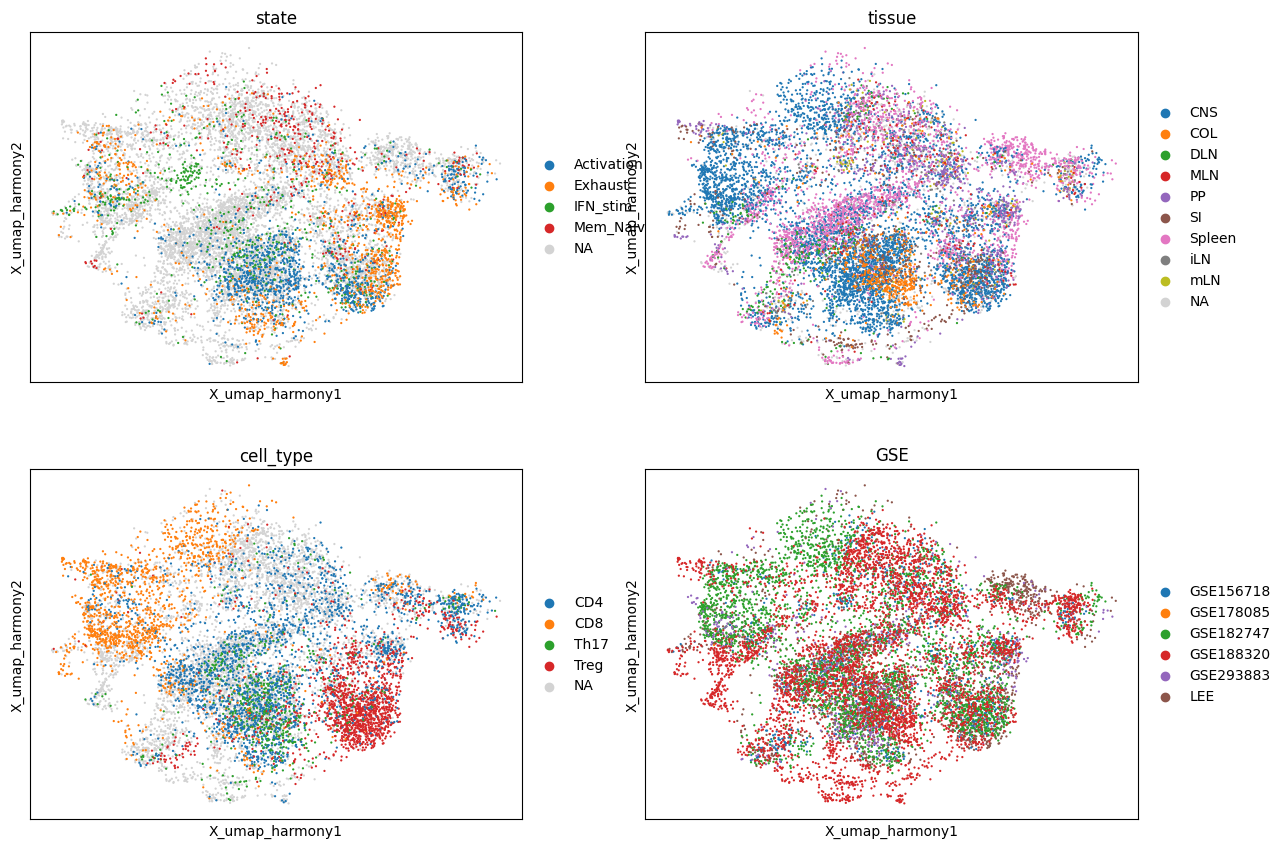

In [595]:
Batch_corrected = True
gene_PCA = 'X_pca_harmony' if Batch_corrected else 'X_pca'
gene_Umap = 'X_umap_harmony' if Batch_corrected else 'X_umap'

sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = 'neighbors_harmony', 
                color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2,)

In [596]:
top_n = 20
sc.tl.rank_genes_groups(mdata["gex"], groupby='tissue', groups = ['CNS'], reference='rest',
                        n_genes = top_n, method='t-test')
rank_df = sc.get.rank_genes_groups_df(mdata["gex"], None)


In [597]:
rank_df.head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,Gm10076,105.023354,5.600612,0.0,0.0
1,Rpl9-ps6,104.952065,6.136094,0.0,0.0
2,Rpl10-ps3,95.152069,4.964133,0.0,0.0
3,Hspa1b,83.808693,8.122895,0.0,0.0
4,Gapdh,83.709061,2.334820,0.0,0.0


## concate TCR features

In [598]:
arrs_tcr = []
for key, value in mdata.obsm.items():
    arrs_tcr.append(value)

In [599]:
view_tcr = np.concatenate(arrs_tcr, axis=1)
view_tcr = np.concatenate([view_tcr, mdata.obs['VDJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1),
                           mdata.obs['VJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1)],  axis=1)

scaler = StandardScaler()
view_tcr = scaler.fit_transform(view_tcr)

In [600]:
mdata.obsm.items()

ItemsView(MuAxisArrays with keys: airr, gex, X_VDJ_1_cdr3_aa_atchley, X_VDJ_1_cdr3_aa_composition, X_VJ_1_cdr3_aa_atchley, X_VJ_1_cdr3_aa_composition, VDJ_1_j_call, VDJ_1_v_call, VJ_1_j_call, VJ_1_v_call)

## train test split by samples

In [601]:
# select data sets as test 
test_ids = ['LEE']
mdata.obs.loc[mdata.obs['GSE'].isin(test_ids), 'set'] = 'test'
mdata.obs.loc[~mdata.obs['GSE'].isin(test_ids), 'set'] = 'train'
mdata.obs['set'].value_counts()

set
train    9856
test     1689
Name: count, dtype: int64

## Unbiased CCA

In [602]:
# Perform Canonical Correlation Analysis separately on train and test sets
view_gene = mdata['gex'].obsm[gene_PCA]
view_gene_scaled = scaler.fit_transform(view_gene)

# Split data based on mdata.obs['set']
train_mask = mdata.obs['set'] == 'train'
test_mask = mdata.obs['set'] == 'test'

view_gene_train = view_gene_scaled[train_mask]
view_gene_test = view_gene_scaled[test_mask]
view_tcr_train = view_tcr[train_mask]
view_tcr_test = view_tcr[test_mask]

print(f"Train set: {view_gene_train.shape[0]} samples")
print(f"Test set: {view_gene_test.shape[0]} samples")

# Fit CCA on train set
# cca = CCA(n_components=4)
cca = TCR_embedings.rCCA(n_components=4, alpha_x=1, alpha_y=10,)

view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)

# Transform test set using fitted CCA
view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)

print(f"\nTrain canonical variates shape: {view_gene_c_train.shape}")
print(f"Test canonical variates shape: {view_gene_c_test.shape}")

# Combine for full dataset storage

view_gene_c = np.zeros((mdata.n_obs, 4))
view_tcr_c = np.zeros((mdata.n_obs, 4))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask] = view_gene_c_test
view_tcr_c[train_mask] = view_tcr_c_train
view_tcr_c[test_mask] = view_tcr_c_test

Train set: 9856 samples
Test set: 1689 samples

Train canonical variates shape: (9856, 4)
Test canonical variates shape: (1689, 4)


In [628]:
importlib.reload(TCR_embedings)

<module 'TCR_embedings' from '/ihome/ylee/yiz133/Code/Data processing/functions/TCR_embedings.py'>

In [626]:
corr_train, corr_test = TCR_embedings.train_test_corr(view_gene_c_train, view_tcr_c_train, view_gene_c_test, view_tcr_c_test)

Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      0.2720          0.1142          0.1578         
Component 2      0.2670          0.2530          0.0140         
Component 3      0.2100          0.1504          0.0596         
Component 4      0.2354          0.0812          0.1542         


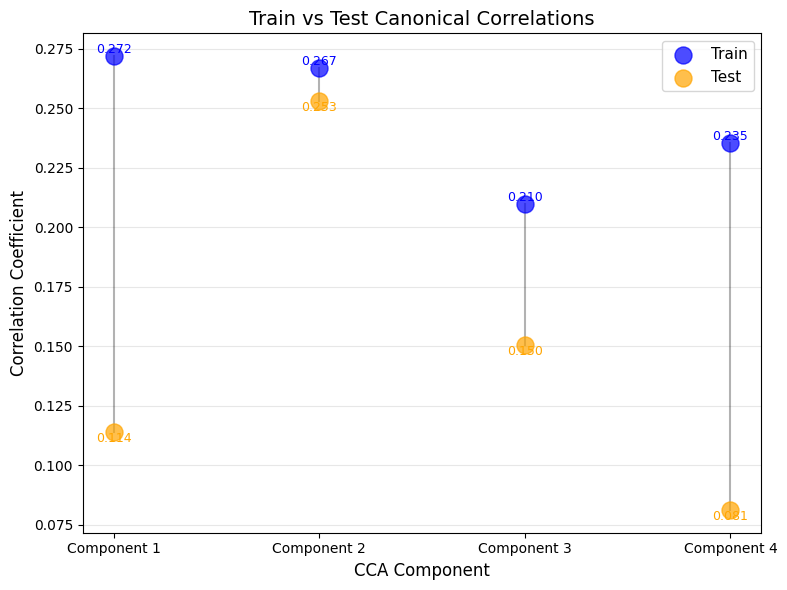

In [630]:
TCR_embedings.plot_train_test_corr(corr_train, corr_test)

### visualize CV scores

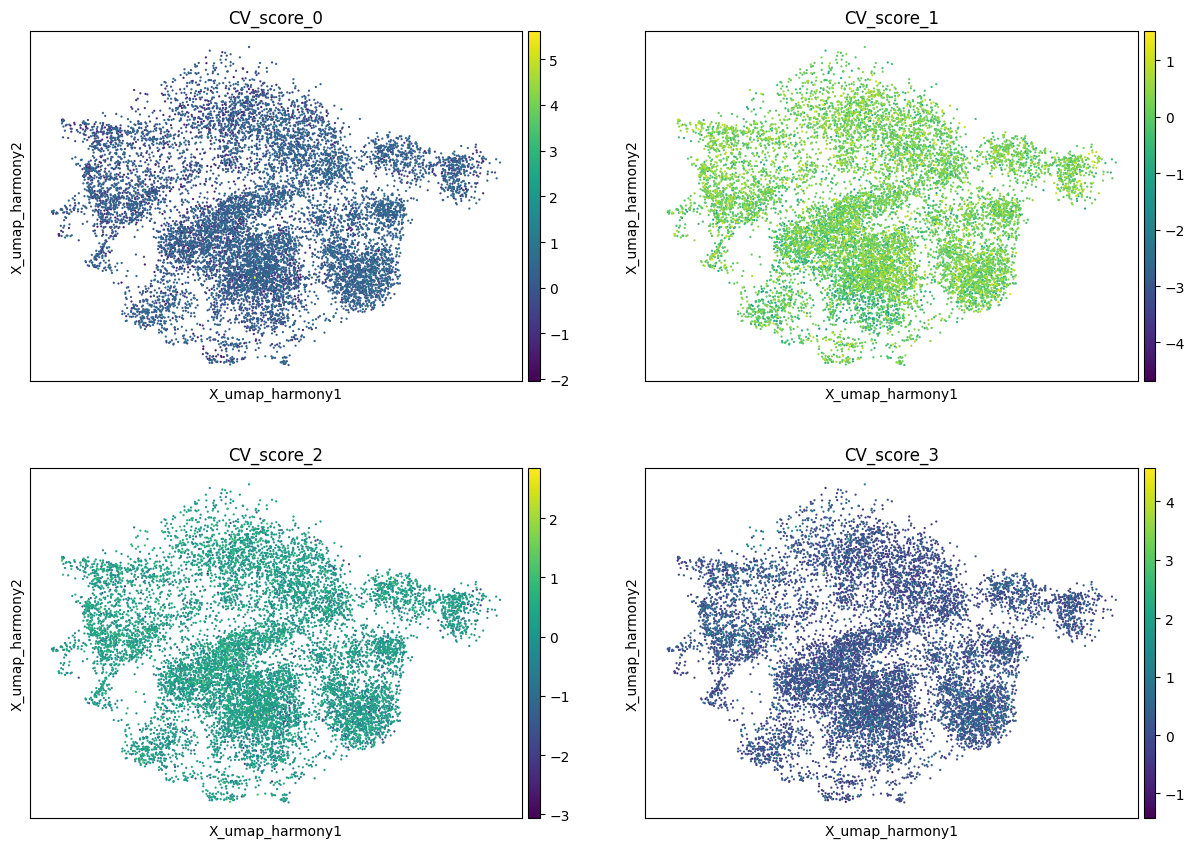

In [605]:
sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = 'neighbors_harmony', 
            color= cv_list, ncols=2,)

In [606]:
cutoff = 0.4

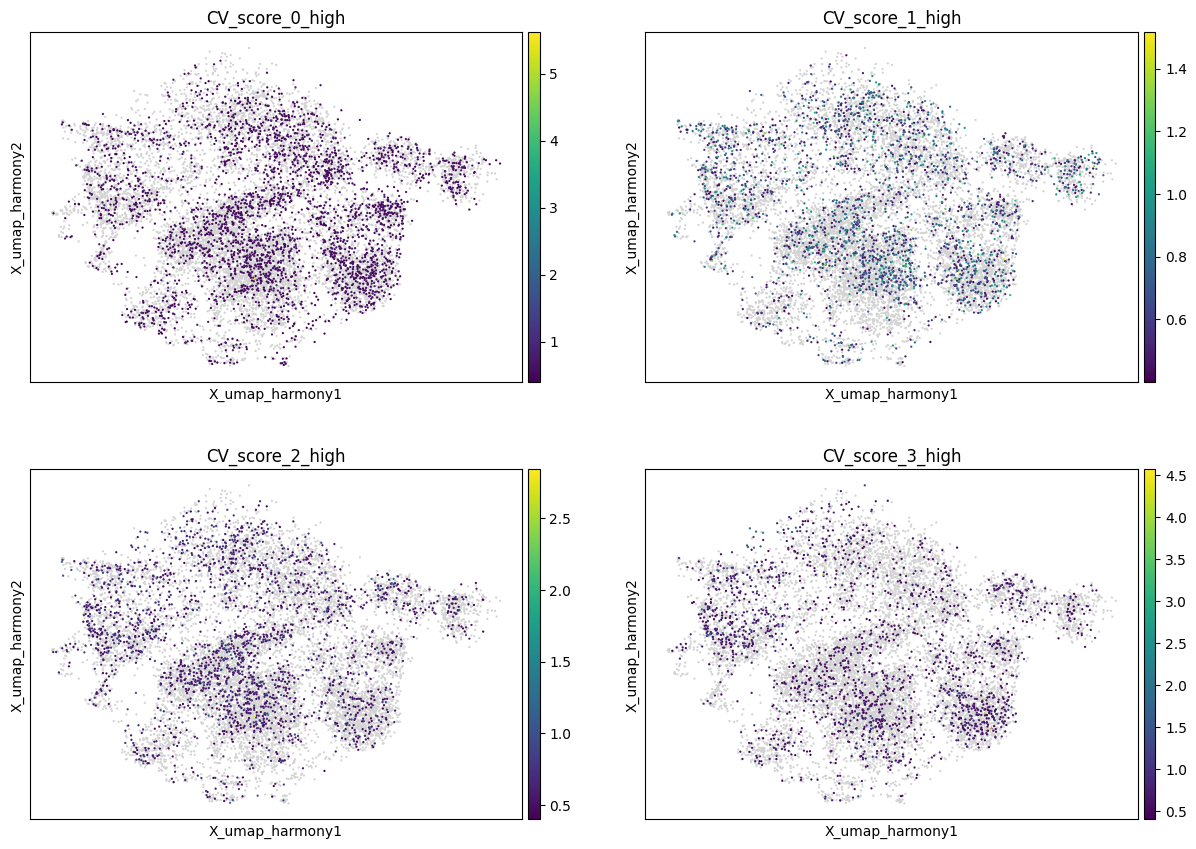

In [607]:
highlight_list = []
for i in range(0, 4):
    cv_name = f'CV_score_{i}'
    tmp_col = cv_name + "_high"
    highlight_list.append(tmp_col)
    
    vals = mdata['gex'].obs[cv_name].copy()
    # mdata['gex'].obs[tmp_col] = np.where(abs(vals) > cutoff, vals, np.nan)
    mdata['gex'].obs[tmp_col] = np.where(vals > cutoff, vals, np.nan)

sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = 'neighbors_harmony', 
            color= highlight_list, ncols=2,)

In [609]:
# what does each high-score cluster consists of
tissue_mask = mdata['gex'].obs['Tissue_group'].isin(['CNS'])
mdata_sub = mdata[test_mask]

all_results = []
abs_target = ['Tissue_group', 'cell_type', 'state']

# Precompute the overall (baseline) pool within the same tissue filter

df_CV = TCR_embedings.subset_fractions_in_CV_scores(4, mdata_sub, abs_target, cutoff)
df_CV

,CV_component,pos_CNS,all_CNS,neg_CNS,pos_not-CNS,all_not-CNS,neg_not-CNS,pos_CD4,all_CD4,neg_CD4,...,neg_Activation,pos_Exhaust,all_Exhaust,neg_Exhaust,pos_IFN_stim,all_IFN_stim,neg_IFN_stim,pos_Mem_Naive,all_Mem_Naive,neg_Mem_Naive
0,CV_score_0,37.93,46.3,45.24,62.07,53.7,54.76,39.22,35.94,31.75,...,35.71,6.68,7.22,7.94,7.97,8.94,7.94,0.65,0.18,NaN
1,CV_score_1,44.17,46.3,58.28,55.83,53.7,41.72,26.70,35.94,44.90,...,39.46,7.77,7.22,7.94,7.77,8.94,9.52,0.97,0.18,NaN
2,CV_score_2,44.10,46.3,56.52,55.90,53.7,43.48,28.82,35.94,42.61,...,40.87,7.29,7.22,11.30,8.68,8.94,8.26,NaN,0.18,0.43
3,CV_score_3,43.37,46.3,50.00,56.63,53.7,50.00,28.31,35.94,35.64,...,39.89,7.23,7.22,6.38,9.94,8.94,6.91,NaN,0.18,NaN


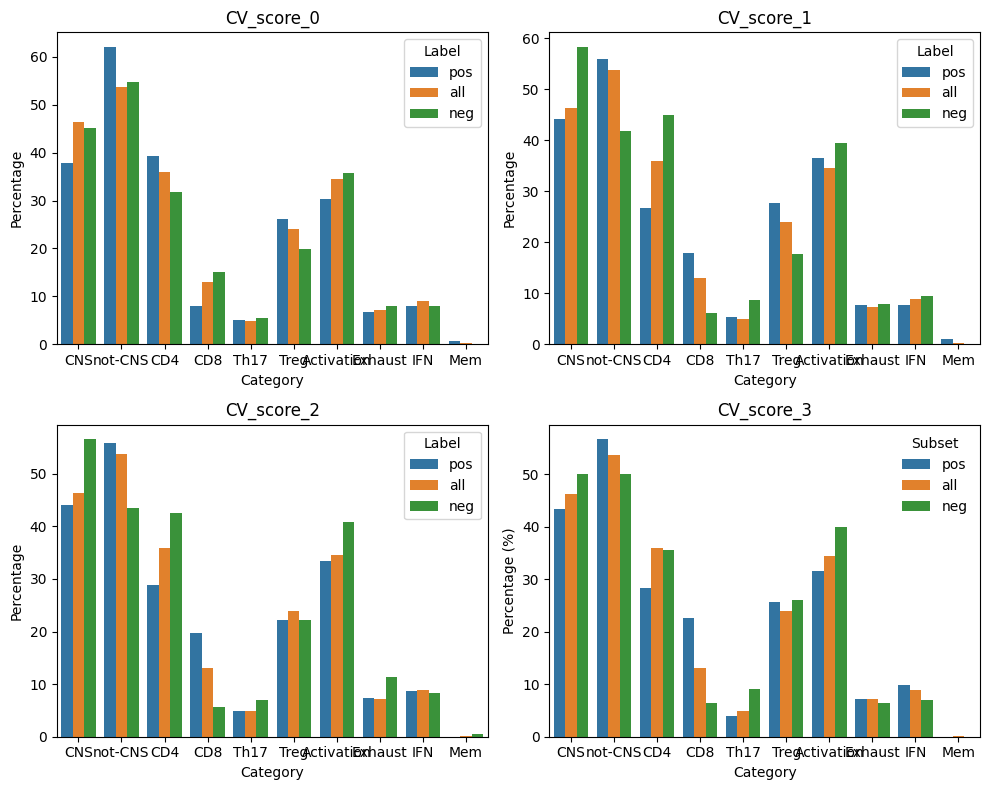

In [610]:
TCR_embedings.plot_subset_fractions_in_CV_scores(df_CV)

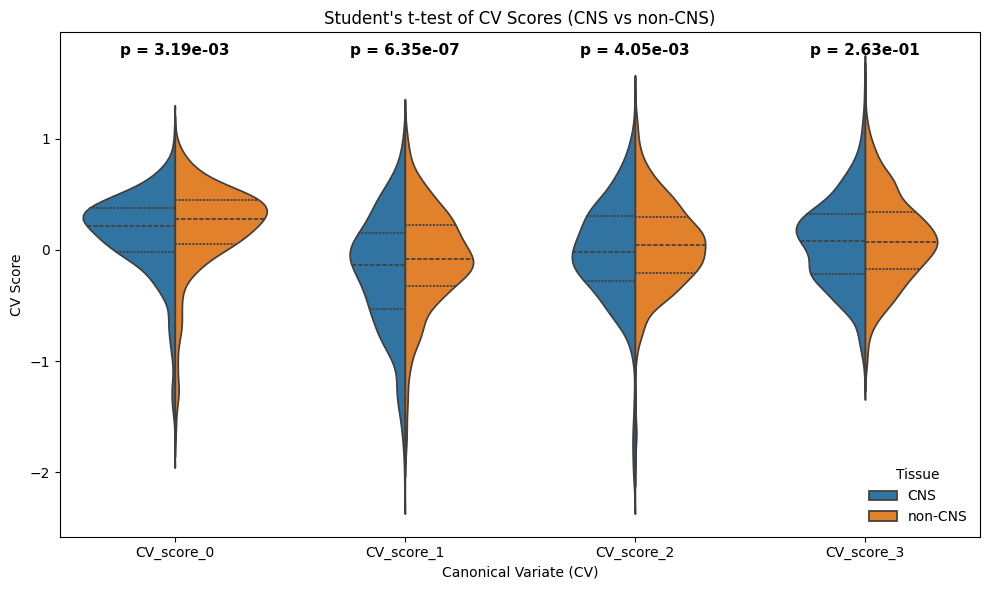

In [611]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
obs = mdata_sub['gex'].obs.copy()

cv_cols = [f'CV_score_{i}' for i in range(4)]
df_long = obs.melt(id_vars='Tissue_group',
                   value_vars=cv_cols,
                   var_name='CV_component',
                   value_name='CV_score')

# ------------------------------------------------------------
# Student's t-test (unpaired)
# ------------------------------------------------------------
p_values = {}
for cv in cv_cols:
    sub = df_long[df_long['CV_component'] == cv]
    cns_scores = sub.loc[sub['Tissue_group'] == 'CNS', 'CV_score']
    non_scores = sub.loc[sub['Tissue_group'] == 'non-CNS', 'CV_score']
    stat, p = ttest_ind(cns_scores, non_scores, equal_var=True, nan_policy='omit')
    p_values[cv] = p

# ------------------------------------------------------------
# Violin plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=df_long,
    x='CV_component',
    y='CV_score',
    hue='Tissue_group',
    split=True,
    inner='box',
    palette={'CNS': 'tab:blue', 'non-CNS': 'tab:orange'},
)

plt.title("Student's t-test of CV Scores (CNS vs non-CNS)")
plt.xlabel('Canonical Variate (CV)')
plt.ylabel('CV Score')
plt.legend(title='Tissue', frameon=False)

# ------------------------------------------------------------
# Annotate p-values above violins
# ------------------------------------------------------------
y_min, y_max = df_long['CV_score'].min(), df_long['CV_score'].max()
offset = (y_max - y_min) * 0.05

for i, cv in enumerate(cv_cols):
    p = p_values.get(cv)
    label = f"p = {p:.2e}" if p is not None else "NA"
    ax.text(i, y_max + offset, label,
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


### rCCA cross vali

In [640]:
view_tcr_c

array([[ 0.4120022 , -0.60296918, -0.5434212 , -0.07277727],
       [ 0.20171472, -0.06698024,  0.69871818, -0.13081596],
       [ 0.4120022 , -0.60296918, -0.5434212 , -0.07277727],
       ...,
       [ 0.55972546,  0.30657696,  0.46734089,  0.48498248],
       [-0.47211243, -0.33739229,  0.11267096, -0.73304885],
       [-1.15606522,  0.88676499,  0.05300743, -0.44172843]],
      shape=(11545, 4))

In [641]:
# feat_alpha_x = [0.1, 1, 10]
# feat_alpha_y = [0.1, 1, 10]
feat_alpha_x = [1]
feat_alpha_y = [1]

TCR_score_CVs = []
CNS_mask = mdata['gex'].obs['Tissue_group'] == 'CNS'

for a_x in feat_alpha_x:
    for a_y in feat_alpha_y:
        cca = TCR_embedings.rCCA(n_components=4, alpha_x=a_x, alpha_y = a_y)
        print('alpha_X='+str(a_x) + 'alpha_y='+str(a_y))
        view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
        view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)
        
        # Combine for full dataset storage 
        view_gene_t = np.zeros((mdata.n_obs, 4))
        view_tcr_t = np.zeros((mdata.n_obs, 4))
        view_gene_t[train_mask] = view_gene_c_train
        view_gene_t[test_mask] = view_gene_c_test
        view_tcr_t[train_mask] = view_tcr_c_train
        view_tcr_t[test_mask] = view_tcr_c_test
        
        TCR_score_CVs.append(view_tcr_t)
        
        CV_CNS = view_tcr_t[CNS_mask]
        cv_notCNS = view_tcr_t[~CNS_mask]
        
        mean_CNS_CVs = np.mean(CV_CNS,axis=0)
        mean_notCNS_CVs = np.mean(cv_notCNS,axis=0)
        
        diff = mean_CNS_CVs - mean_notCNS_CVs
        print(diff)

        # TCR_embedings.train_test_corr(view_gene_c_train, view_tcr_c_train, view_gene_c_test, view_tcr_c_test)


alpha_X=1alpha_y=1
[-0.18404041  0.05360762 -0.06878481  0.18409893]


### correlations

In [612]:
# ANOVA tests: comparing all groups within each abs_target
from scipy.stats import f_oneway

anova_results = []

for i in range(0,4):
    cv_name = f'CV_score_{i}'
    
    for col in abs_target:
        # Get unique categories
        categories = mdata['gex'].obs[col].dropna().unique()
        
        # Collect all groups for this variable
        groups = []
        for cat in categories:
            group_data = mdata['gex'].obs[mdata['gex'].obs[col] == cat][cv_name].dropna().values
            if len(group_data) > 0:
                groups.append(group_data)
        
        # Perform ANOVA comparing all groups
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            
            anova_results.append({
                'CV_component': cv_name,
                'variable': col,
                'n_groups': len(groups),
                'F_statistic': round(f_stat, 4),
                'p_value': f'{p_value:.4e}',
                'significant': 'Yes' if p_value < 0.05 else 'No'
            })

df_anova = pd.DataFrame(anova_results)
# df_anova


In [613]:
# Calculate Pearson correlation between marker genes and CV scores
from scipy.stats import pearsonr
import seaborn as sns
    
def pearson_corr(adata, var1, markers, var_type='gene'):
    corr_results = []
    
    for cv_name in var1:
        cv_scores = adata.obs[cv_name].values

        for gene in markers:
            if gene in adata.var_names or gene in adata.obs:
                if var_type =='gene':
                    # Get gene expression values
                    gene_expr = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten()
                
                if var_type =='obs':
                    # Get gene set scores
                    gene_expr = gene_expr = adata.obs[gene].to_numpy().flatten() 

                # Calculate Pearson correlation
                corr, p_value = pearsonr(gene_expr, cv_scores)

                corr_results.append({
                    'CV_component': cv_name,
                    'gene': gene,
                    'pearson_r': round(corr, 4),
                    'p_value': f'{p_value:.4e}',
                    'significant': 'Yes' if p_value < 0.05 else 'No'
                })
            else:
                print(f"Warning: Input '{gene}' not found in dataset")

    df_gene_corr = pd.DataFrame(corr_results)
    corr_matrix = df_gene_corr.pivot(index='CV_component', columns='gene', values='pearson_r')
    return corr_matrix
    
    

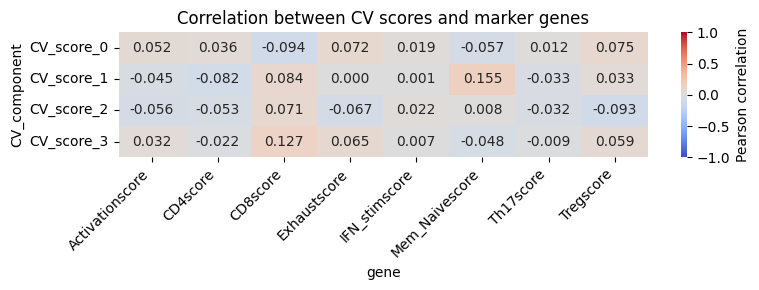

In [614]:
# Create the heatmap
cv_obs_name = [f'CV_score_{i}' for i in range(4)]
scores = ['CD4score', 'CD8score', 'Tregscore', 'Th17score',
          'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore',]

corr_matrix_obs = pearson_corr(mdata['gex'], cv_obs_name, scores, var_type='obs')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_obs, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and marker genes')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

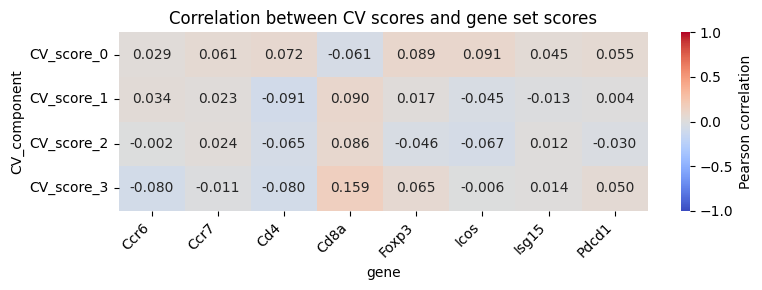

In [615]:
marker_genes = ['Cd4','Cd8a', 'Foxp3', 'Ccr6', 'Il17', 'Isg15', 'Icos', 'Pdcd1', 'Ccr7']
corr_matrix_genes = pearson_corr(mdata['gex'], cv_obs_name, marker_genes, var_type='gene')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_genes, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and gene set scores')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

In [616]:
aa

NameError: name 'aa' is not defined

## biased logistic regression

In [ ]:
# Logistic Regression: predict CNS vs rest using TCR features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Create binary label: CNS vs rest
y = (mdata['gex'].obs['tissue'] == 'CNS').astype(int)

# Split data by fractions
# X_train, X_test, y_train, y_test = train_test_split(view_tcr, y, test_size=0.2, random_state=42, stratify=y)

# Split data based on mdata.obs['set']
train_mask = mdata.obs['set'] == 'train'
test_mask = mdata.obs['set'] == 'test'

X_train = view_tcr[train_mask]
X_test = view_tcr[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Apply RandomOverSampler to balance classes
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)
# X_test, y_test = ros.fit_resample(X_test, y_test)

print(f"\nAfter oversampling:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Train Logistic Regression
lr_model = LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
# Predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\n{'='*60}")
print("Performance on Test Set:")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-CNS', 'CNS']))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
# Plot distribution of decision function for both classes
# score_p = lr_model.decision_function(X_test)
# decision_scores = (score_p - np.mean(score_p)) / np.std(score_p)

decision_scores = y_pred_proba

# Separate scores by class
scores_non_cns = decision_scores[y_test == 0]
scores_cns = decision_scores[y_test == 1]

# Create the plot
plt.figure(figsize=(8,4))
plt.hist(scores_non_cns, bins=50, alpha=0.6, label='Non-CNS', color='blue', edgecolor='black')
plt.hist(scores_cns, bins=50, alpha=0.6, label='CNS', color='red', edgecolor='black')
plt.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Decision boundary')
plt.xlabel('Decision Function Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Decision Function Scores by Class', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Non-CNS scores - Mean: {scores_non_cns.mean():.4f}, Std: {scores_non_cns.std():.4f}")
print(f"CNS scores - Mean: {scores_cns.mean():.4f}, Std: {scores_cns.std():.4f}")
from scipy.stats import ks_2samp
stat, p = ks_2samp(scores_non_cns, scores_cns)
print("KS statistic:", stat, "p-value:", p)

In [ ]:
aa

# cross-set test

In [ ]:
#### Compare performance across all GSE subsets as test groups
# Get unique GSE values
unique_gses = mdata.obs['GSE'].unique()
print(f"Found {len(unique_gses)} unique GSE values: {unique_gses.tolist()}")

# Store results for comparison
results_summary = []


In [ ]:
# Loop through each GSE as test set
for test_gse in unique_gses:
    print(f"\n{'='*80}")
    print(f"Testing with {test_gse} as test set")
    print(f"{'='*80}")
    
    # Set train/test split
    mdata.obs.loc[mdata.obs['GSE'].isin([test_gse]), 'set'] = 'test'
    mdata.obs.loc[~mdata.obs['GSE'].isin([test_gse]), 'set'] = 'train'
    
    train_size = (mdata.obs['set'] == 'train').sum()
    test_size = (mdata.obs['set'] == 'test').sum()
    print(f"Train set: {train_size} samples, Test set: {test_size} samples")
    
    # Prepare feature arrays (same as before)
    arrs_tcr = []
    for key, value in mdata.obsm.items():
        arrs_tcr.append(value)
    
    view_tcr = np.concatenate(arrs_tcr, axis=1)
    view_tcr = np.concatenate([view_tcr, mdata.obs['VDJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1),
                               mdata.obs['VJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1)], axis=1)
    
    scaler = StandardScaler()
    view_tcr = scaler.fit_transform(view_tcr)
    
    # Split data
    train_mask = mdata.obs['set'] == 'train'
    test_mask = mdata.obs['set'] == 'test'
    
    X_train = view_tcr[train_mask]
    X_test = view_tcr[test_mask]
    
    # Create binary label: CNS vs rest
    y = (mdata['gex'].obs['tissue'] == 'CNS').astype(int)
    y_train = y[train_mask]
    y_test = y[test_mask]
    
    # ===== Logistic Regression Evaluation =====
    print(f"\n--- Logistic Regression Evaluation ---")
    
    # Apply RandomOverSampler to balance classes
    from imblearn.over_sampling import RandomOverSampler
    ros = RandomOverSampler(random_state=42)
    X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)
    
    # Train Logistic Regression
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_balanced, y_train_balanced)
    
    # Predictions
    y_pred = lr_model.predict(X_test)
    y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    lr_accuracy = accuracy_score(y_test, y_pred)
    lr_roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy: {lr_accuracy:.4f}")
    print(f"ROC AUC: {lr_roc_auc:.4f}")
    
    # ===== CCA Evaluation =====
    print(f"\n--- CCA Evaluation ---")
    
    # Prepare gene expression view
    view_gene = mdata['gex'].obsm[gene_PCA]
    scaler_gene = StandardScaler()
    view_gene_scaled = scaler_gene.fit_transform(view_gene)
    
    view_gene_train = view_gene_scaled[train_mask]
    view_gene_test = view_gene_scaled[test_mask]
    view_tcr_train = view_tcr[train_mask]
    view_tcr_test = view_tcr[test_mask]
    
    # Fit CCA on train set
    cca = CCA(n_components=4)
    view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
    
    # Transform test set
    view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)
    
    # Calculate correlations for each component
    cca_correlations_train = []
    cca_correlations_test = []
    
    for i in range(4):
        corr_train = np.corrcoef(view_gene_c_train[:, i], view_tcr_c_train[:, i])[0, 1]
        corr_test = np.corrcoef(view_gene_c_test[:, i], view_tcr_c_test[:, i])[0, 1]
        cca_correlations_train.append(corr_train)
        cca_correlations_test.append(corr_test)
    
    # Average correlation (can also use max or sum)
    avg_train_corr = np.mean(cca_correlations_train)
    avg_test_corr = np.mean(cca_correlations_test)
    cca_drop = avg_train_corr - avg_test_corr  # Generalization gap
    
    print(f"Average Train Correlation: {avg_train_corr:.4f}")
    print(f"Average Test Correlation: {avg_test_corr:.4f}")
    print(f"Generalization Gap: {cca_drop:.4f}")
    
    # Store results
    result = {
        'test_gse': test_gse,
        'train_size': train_size,
        'test_size': test_size,
        'lr_accuracy': lr_accuracy,
        'lr_roc_auc': lr_roc_auc,
        'cca_train_corr': avg_train_corr,
        'cca_test_corr': avg_test_corr,
        'cca_generalization_gap': cca_drop,
        'cca_comp1_train': cca_correlations_train[0],
        'cca_comp1_test': cca_correlations_test[0],
        'cca_comp2_train': cca_correlations_train[1],
        'cca_comp2_test': cca_correlations_test[1],
        'cca_comp3_train': cca_correlations_train[2],
        'cca_comp3_test': cca_correlations_test[2],
        'cca_comp4_train': cca_correlations_train[3],
        'cca_comp4_test': cca_correlations_test[3],
    }
    results_summary.append(result)
    
    print(f"\nCompleted evaluation for {test_gse}")

# Convert results to DataFrame
results_df = pd.DataFrame(results_summary)


In [ ]:
# Identify best performing test groups
print(f"\n{'='*80}")
print("BEST PERFORMING TEST GROUPS")
print(f"{'='*80}")

# Best by Logistic Regression Accuracy
best_lr_acc = results_df.loc[results_df['lr_accuracy'].idxmax()]
print(f"\nBest Logistic Regression Accuracy:")
print(f"  Test GSE: {best_lr_acc['test_gse']}")
print(f"  Accuracy: {best_lr_acc['lr_accuracy']:.4f}")
print(f"  ROC AUC: {best_lr_acc['lr_roc_auc']:.4f}")

# Best by Logistic Regression ROC AUC
best_lr_auc = results_df.loc[results_df['lr_roc_auc'].idxmax()]
print(f"\nBest Logistic Regression ROC AUC:")
print(f"  Test GSE: {best_lr_auc['test_gse']}")
print(f"  Accuracy: {best_lr_auc['lr_accuracy']:.4f}")
print(f"  ROC AUC: {best_lr_auc['lr_roc_auc']:.4f}")

# Best by CCA Test Correlation (highest generalization)
best_cca_test = results_df.loc[results_df['cca_test_corr'].idxmax()]
print(f"\nBest CCA Test Correlation (Best Generalization):")
print(f"  Test GSE: {best_cca_test['test_gse']}")
print(f"  Test Correlation: {best_cca_test['cca_test_corr']:.4f}")
print(f"  Train Correlation: {best_cca_test['cca_train_corr']:.4f}")
print(f"  Generalization Gap: {best_cca_test['cca_generalization_gap']:.4f}")

# Best by smallest CCA generalization gap (most stable)
best_cca_gap = results_df.loc[results_df['cca_generalization_gap'].idxmin()]
print(f"\nBest CCA Generalization (Smallest Gap):")
print(f"  Test GSE: {best_cca_gap['test_gse']}")
print(f"  Test Correlation: {best_cca_gap['cca_test_corr']:.4f}")
print(f"  Train Correlation: {best_cca_gap['cca_train_corr']:.4f}")
print(f"  Generalization Gap: {best_cca_gap['cca_generalization_gap']:.4f}")

# Combined score (normalized metrics)
results_df['combined_score'] = (
    results_df['lr_roc_auc'].rank(pct=True) * 0.5 +  # 50% weight on LR ROC AUC
    results_df['cca_test_corr'].rank(pct=True) * 0.3 +  # 30% weight on CCA test corr
    (1 - results_df['cca_generalization_gap'].rank(pct=True) / results_df['cca_generalization_gap'].max()) * 0.2  # 20% weight on small gap
)

best_combined = results_df.loc[results_df['combined_score'].idxmax()]
print(f"\nBest Combined Score:")
print(f"  Test GSE: {best_combined['test_gse']}")
print(f"  Combined Score: {best_combined['combined_score']:.4f}")
print(f"  LR ROC AUC: {best_combined['lr_roc_auc']:.4f}")
print(f"  CCA Test Correlation: {best_combined['cca_test_corr']:.4f}")
print(f"  CCA Generalization Gap: {best_combined['cca_generalization_gap']:.4f}")

# Display sorted results
print(f"\n{'='*80}")
print("RESULTS SORTED BY COMBINED SCORE")
print(f"{'='*80}")
results_df_sorted = results_df.sort_values('combined_score', ascending=False)
print(results_df_sorted[['test_gse', 'lr_accuracy', 'lr_roc_auc', 'cca_test_corr', 'cca_generalization_gap', 'combined_score']].to_string(index=False))


In [ ]:
# Visualize performance comparison across test groups
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Logistic Regression ROC AUC
axes[0, 0].bar(results_df['test_gse'], results_df['lr_roc_auc'], color='steelblue', alpha=0.7)
axes[0, 0].set_ylabel('ROC AUC', fontsize=12)
axes[0, 0].set_title('Logistic Regression ROC AUC by Test GSE', fontsize=13, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 0].legend()

# Plot 2: CCA Test Correlation
axes[0, 1].bar(results_df['test_gse'], results_df['cca_test_corr'], color='coral', alpha=0.7)
axes[0, 1].set_ylabel('Average Correlation', fontsize=12)
axes[0, 1].set_title('CCA Test Correlation by Test GSE', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: CCA Generalization Gap
axes[1, 0].bar(results_df['test_gse'], results_df['cca_generalization_gap'], color='gold', alpha=0.7)
axes[1, 0].set_ylabel('Generalization Gap', fontsize=12)
axes[1, 0].set_title('CCA Generalization Gap (Train - Test)', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Combined Score
axes[1, 1].bar(results_df_sorted['test_gse'], results_df_sorted['combined_score'], color='mediumseagreen', alpha=0.7)
axes[1, 1].set_ylabel('Combined Score', fontsize=12)
axes[1, 1].set_title('Combined Performance Score (Sorted)', fontsize=13, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional plot: CCA component-wise comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.2

# Plot test correlations for each component
for i in range(4):
    ax.bar(x + i*width, results_df[f'cca_comp{i+1}_test'], width, 
           label=f'Component {i+1}', alpha=0.8)

ax.set_xlabel('Test GSE', fontsize=12)
ax.set_ylabel('Test Correlation', fontsize=12)
ax.set_title('CCA Test Correlations by Component', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['test_gse'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Save

In [ ]:
# import anndata as ad
# ad.settings.allow_write_nullable_strings = True
# mdata.write('merged_EAE_TCRemb.h5mu')